# Assignment 9 - Regression & Logistic Regression

## Question 1: Introduction to Regression Analysis

### a) What Does Regression Mean in Simple Words?

Regression is a supervised machine learning and statistical technique that finds the mathematical relationship between one or more input variables (features) and a continuous numerical output (target). In simple terms, regression answers: 'Given what I know about inputs, what number should the output be?' It draws the best-fitting mathematical function through historical data points and uses that function to predict the output for any new input. For example, given a person's years of experience, regression predicts their salary.

### b) Why Is Regression Used to Predict Continuous Values?

Regression is specifically designed for continuous, quantitative outcomes — values that can be any real number within a range, such as 45230.75 or 3.14. The output can take infinitely many possible values. The model maps inputs to a number on the real number line, not to discrete categories. In contrast, classification predicts a label from a finite set. When the outcome of interest is a measurable quantity — price, temperature, revenue, or salary — regression is the appropriate technique because it outputs a number, not a category.

### c) Three Real-World Use Cases of Regression

- **House Price Prediction:** Given area, bedrooms, location, and property age, a regression model predicts the selling price. Real estate platforms use regression for automated valuations.
- **Salary Prediction:** Given years of experience, education level, and job role, a regression model predicts expected annual compensation. Companies use this for benchmarking and HR planning.
- **Sales Forecasting:** Given historical sales, marketing spend, and seasonal indicators, regression predicts next month's revenue. Retailers use this for inventory and budget planning.

### d) Difference Between Regression and Classification

- **Regression:** Predicts a continuous numerical value. Output is any real number. Evaluated using MAE, MSE, R-squared. Example: Predicting a student's exam score (73.2/100).
- **Classification:** Predicts a discrete class label from a fixed set. Output is one of a finite number of categories. Evaluated using accuracy, precision, recall, F1. Example: Predicting whether an email is spam or not spam.

Key rule: If the answer is a number on a scale, use regression. If the answer is a category, use classification.


## Question 2: Regression Data and Linear Regression

### a) Features X and Target Y in Regression

- **Features X (Independent Variables):** The input variables used for prediction. What we know or can measure. In house price prediction, X includes area, number of rooms, and location. Can be a single variable (simple regression) or multiple variables (multiple regression).
- **Target Y (Dependent Variable):** The output we want to predict. In house price prediction, Y is the sale price. The model learns the mapping f(X) = Y from training data and uses it to predict Y for new inputs.

### b) Single-Variable Regression with an Example

Single-variable (simple) regression uses exactly one feature X to predict target Y: Y = b0 + b1*X. Example: Predicting a student's exam score (Y) based on hours studied (X). If the fitted equation is Score = 40 + 5 * Hours, a student who studies 6 hours is predicted to score 40 + 5*6 = 70 marks.

### c) What Is Linear Regression?

Linear regression is a supervised ML algorithm that models the relationship between one or more input features and a continuous target as a linear function. The algorithm finds the values of intercept and slope(s) that minimize prediction errors using the Least Squares method.

> **Y = b0 + b1\*X1 + b2\*X2 + ... + bn\*Xn**

Linear regression is valued for its interpretability, simplicity, speed, and as the foundation for more complex models.

### d) When Does Linear Regression Work Well?

- When the relationship between features and target is truly or approximately linear.
- When features are independent (no multicollinearity).
- When residuals are normally distributed with constant variance (homoscedasticity).
- When there are no extreme outliers — linear regression is sensitive to them.
- When there are sufficient observations relative to features (at least 10-20 per feature).


## Question 3: Linear Regression Equation and Prediction

### a) The Linear Regression Equation

Simple (single-variable) linear regression:

> **Y = b0 + b1 \* X**

Multiple linear regression:

> **Y = b0 + b1\*X1 + b2\*X2 + ... + bn\*Xn**

### b) Intercept and Coefficient (Slope)

- **Intercept (b0):** The value of Y when all features X equal zero. The baseline prediction. Geometrically, where the regression line crosses the Y-axis. In the salary equation, an intercept of 15000 means the base predicted salary for zero experience is Rs. 15,000.
- **Coefficient/Slope (b1):** The change in Y for every one-unit increase in X, holding other features constant. Positive coefficient: Y increases with X. Negative: Y decreases with X. A coefficient of 5000 for Experience means each additional year adds Rs. 5,000 to predicted salary.

### c) How the Equation Is Used for Prediction

Once trained, substitute the known feature values (X values) into the equation and calculate Y. The equation is a mathematical formula that translates input measurements into a predicted output. This interpretability — seeing exactly how much each feature contributes — is a key strength of linear regression.

### d) Prediction: Salary for 4 Years of Experience

Given: Salary = 15000 + 5000 x Experience. Substituting Experience = 4:

> **Salary = 15000 + 5000 \* 4 = 15000 + 20000 = Rs. 35,000**

A person with 4 years of experience is predicted to earn Rs. 35,000.


In [1]:
# Question 3d: Salary prediction calculation
intercept = 15000
coefficient = 5000
experience = 4

salary = intercept + coefficient * experience
print(f"Predicted Salary for {experience} years of experience = Rs. {salary}")


Predicted Salary for 4 years of experience = Rs. 35000


## Question 4: Prediction Errors, Best Fit Line, and Least Squares

### a) Actual Value vs Predicted Value

- **Actual Value (y_i):** The true observed value from the real dataset — what actually happened. Example: A house actually sold for Rs. 45,00,000.
- **Predicted Value (y_hat_i):** The value estimated by the regression model using the learned equation. Example: The model predicts Rs. 43,50,000.

The gap between actual and predicted tells us how well the model performs. A perfect model would have actual = predicted for every point.

### b) What Is a Residual?

> **Residual = Actual (y_i) - Predicted (y_hat_i)**

Positive residual: model underestimated. Negative: model overestimated. Residuals carry diagnostic information — analyzing their patterns reveals non-linearity, heteroscedasticity, and outliers. A good model has residuals randomly scattered around zero with no systematic pattern.

### c) What Does Best Fit Line Mean?

The best fit line is the single straight line most accurately representing the overall trend — closest to all data points simultaneously in the vertical direction. No single line can pass through every point in a real dataset. Best fit means minimizing total vertical distances between data points and the line, balancing over- and under-predictions to achieve the smallest overall error.

### d) Least Squares Method and Why Squared Errors Are Used

The Least Squares method finds coefficients b0 and b1 that minimize the Sum of Squared Residuals (SSR):

> **SSR = Sum of (y_i - y_hat_i)^2 for all data points**

- Squaring prevents positive and negative errors from cancelling — simple sum of raw errors would be zero for a terrible model.
- Amplifies large errors: an error of 10 contributes 100; an error of 2 contributes only 4. Forces the model to avoid catastrophic predictions.
- Mathematical convenience: the squared error function is smooth and differentiable, enabling calculus-based closed-form or gradient descent solutions.


## Question 5: Hands-On Simple Linear Regression Using Python

The code below loads a small experience-vs-salary dataset, splits it into train/test sets, fits a `LinearRegression` model, prints the learned equation and evaluation metrics, and plots the regression line against the actual data.


Intercept (b0): 8750.00
Coefficient (b1): 4500.00
Equation: Salary = 8750.00 + 4500.00 * Experience
MAE: 500.00
MSE: 312500.00
R2 Score: 0.9988


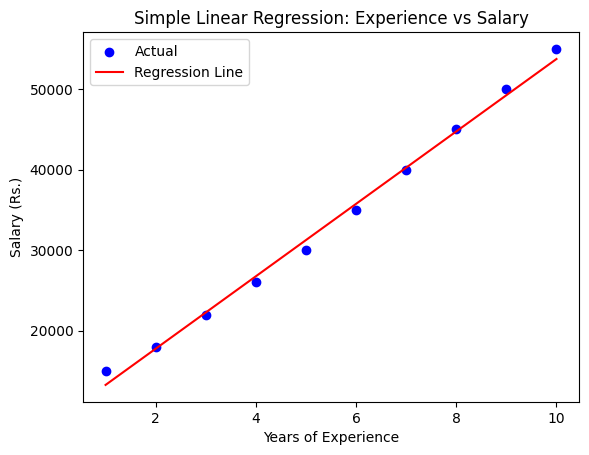

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# a) Load a simple dataset
data = {
    'experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'salary': [15000, 18000, 22000, 26000, 30000,
               35000, 40000, 45000, 50000, 55000]
}
df = pd.DataFrame(data)

# b) Separate features X and target Y
X = df[['experience']]  # 2D array required by sklearn
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# c) Train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# d) Make predictions and print coefficient and intercept
y_pred = model.predict(X_test)

print(f'Intercept (b0): {model.intercept_:.2f}')
print(f'Coefficient (b1): {model.coef_[0]:.2f}')
print(f'Equation: Salary = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Experience')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')

# Plot regression line
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (Rs.)')
plt.title('Simple Linear Regression: Experience vs Salary')
plt.legend()
plt.show()


## Question 6: Model Evaluation Metrics in Regression

### a) Mean Absolute Error (MAE)

> **MAE = (1/n) \* Sum of |y_i - y_hat_i|**

MAE is the average absolute difference between actual and predicted values. An MAE of Rs. 2,000 means predictions are off by Rs. 2,000 on average. Easy to interpret (same units as target). Treats all errors equally — not sensitive to outliers. Use MAE when large errors should not be penalized more than small ones.

### b) Mean Squared Error (MSE)

> **MSE = (1/n) \* Sum of (y_i - y_hat_i)^2**

MSE squares the errors before averaging, giving much more weight to large deviations. A prediction off by 10 contributes 100 to MSE; off by 2 contributes only 4. MSE is the loss function minimized during linear regression training. Units are the square of the target variable (e.g., Rs^2). RMSE (square root of MSE) restores original units for interpretability.

### c) R-Squared Score (R^2)

> **R^2 = 1 - (SS_residual / SS_total)**

R^2 measures the proportion of variance in Y explained by the model's features. R^2 = 1.0: perfect. R^2 = 0.85: model explains 85% of variance. R^2 = 0.0: model is no better than predicting the mean. R^2 < 0: model is worse than the mean. Most widely used single metric for regression comparison. Adjusted R^2 penalizes for adding irrelevant features.

### d) Why Not Judge a Regression Model Only by Predictions?

- Overfitting risk: Near-perfect training predictions may mask poor generalization to new data. Always evaluate on a held-out test set.
- Multiple metrics tell the full story: Low MAE with poor R^2 or high variance in residuals indicates a partially useful but unreliable model.
- Residual analysis: Systematic patterns in residuals (curves, funnels) reveal violated assumptions that metrics alone don't expose.
- Business sanity check: Statistically good predictions might be economically nonsensical (e.g., negative salary). Domain validation is essential.
- Extrapolation risk: Good predictions within the training range may fail badly for extreme out-of-range inputs.


## Question 7: Regression Assumptions and Multicollinearity

### a) Why Are Regression Assumptions Important?

Linear regression is built on mathematical assumptions. When they hold, the OLS estimator is the Best Linear Unbiased Estimator (BLUE) — coefficient estimates are unbiased with minimum variance. When violated, coefficients may be biased or unreliable, p-values become invalid, confidence intervals are incorrect, and predictions may be systematically wrong. Verifying assumptions is a required step, not optional.

### b) Linearity, Independence of Errors, and Homoscedasticity

- **Linearity:** The X-Y relationship must be linear. A curved true relationship causes systematic underfitting. Detection: residuals vs fitted values plot — random scatter confirms linearity; a curved pattern indicates non-linearity. Fix: add polynomial features or use non-linear models.
- **Independence of Errors:** Residuals for different observations must be independent. Most commonly violated in time series data (autocorrelation). Detection: Durbin-Watson test. Fix: use time series models or add lag features.
- **Homoscedasticity:** Residual variance must be constant across all X values. Heteroscedasticity (fan/funnel pattern in residuals) causes underestimated standard errors and invalid hypothesis tests. Detection: residuals vs fitted plot. Fix: log-transform Y or use weighted least squares.

### c) Normality of Residuals

Residuals should be approximately normally distributed around zero. This ensures validity of t-tests on coefficients, accurate confidence intervals, and meaningful p-values. Detection: Q-Q plot (residuals should align on a diagonal) or Shapiro-Wilk test. Note: with large samples (n > 30), the CLT reduces the importance of this assumption — coefficient sampling distributions become normal regardless.

### d) Multicollinearity and Why It Is Harmful

Multicollinearity occurs when two or more features are highly correlated — one feature can be approximately predicted from others. Example: 'number of rooms' and 'total area' in a house price model.

- Unstable coefficients: Small data changes cause large swings in coefficient values.
- Inflated standard errors: Model cannot isolate individual feature contributions.
- Wrong sign: A feature's coefficient may appear negative when it should be positive.
- Detection: Variance Inflation Factor (VIF) — VIF > 5-10 indicates multicollinearity. Also use correlation heatmaps.
- Fix: Remove correlated features, apply PCA, or use Ridge Regression which handles multicollinearity by distributing coefficient weight.


## Question 8: Overfitting and Regularization in Regression

### a) What Is Overfitting in Regression?

Overfitting occurs when a regression model learns the training data too well — capturing noise and random fluctuations specific to the training set rather than the true underlying pattern. An overfit model has very low training error but high test error, failing to generalize to new data. Signs: training R^2 very high (0.99) but test R^2 much lower (0.65). The gap between training and test performance is the key indicator. High-degree polynomial regression is a common cause — it creates curves that pass through every training point but wiggle wildly for new inputs.

### b) What Is Regularization?

Regularization adds a penalty term to the loss function to discourage overly complex models by shrinking coefficient magnitudes:

> **Regularized Loss = MSE + lambda \* Penalty on coefficients**

Lambda (alpha) controls shrinkage strength. Higher lambda: simpler model (more shrinkage, risk of underfitting). Lower lambda: complex model (less shrinkage, risk of overfitting). Regularization prevents any feature from dominating the model, improving generalization.

### c) Ridge Regression (L2 Regularization)

> **Ridge Loss = MSE + lambda \* Sum(b_i^2)**

- Shrinks all coefficients towards zero but never exactly to zero — all features remain in the model.
- Effective when many features are relevant but individual contributions are small.
- Excellent for multicollinearity — distributes weight among correlated features.
- Lambda = 0 reduces to standard linear regression. Tuned via cross-validation.
- sklearn: `from sklearn.linear_model import Ridge; model = Ridge(alpha=1.0)`

### d) Lasso Regression and Feature Selection (L1 Regularization)

> **Lasso Loss = MSE + lambda \* Sum(|b_i|)**

- Shrinks some coefficients to exactly zero — automatic feature selection by eliminating irrelevant features.
- Produces sparse models: selects the most important features and discards the rest.
- Useful when many features exist but only a few are truly predictive.
- Less effective than Ridge when many features are genuinely relevant (arbitrarily zeroes correlated ones).
- Elastic Net combines L1 + L2 for a balance between shrinkage and selection.
- sklearn: `from sklearn.linear_model import Lasso; model = Lasso(alpha=0.1)`


## Question 9: Logistic Regression Basics and Sigmoid Function

### a) What Type of Problem Is Logistic Regression Used For?

Logistic regression is used for binary classification — where Y has exactly two possible classes: 0 or 1, Yes or No, Spam or Not Spam. Despite its name, it is a classification algorithm, not regression. It predicts the probability that an input belongs to the positive class (class 1), then applies a decision threshold (typically 0.5) to assign a class label. Examples: Customer churn prediction (yes/no), email spam detection, loan default prediction, medical disease diagnosis. It can be extended to multiclass problems using One-vs-Rest or Softmax.

### b) What Does the Sigmoid Function Do?

The sigmoid function transforms any real-valued number into a value strictly between 0 and 1:

> **sigmoid(z) = 1 / (1 + e^(-z))**

Where z = b0 + b1\*X1 + b2\*X2 + ... is the linear combination of features (identical to linear regression).

- When z >> 0 (large positive): sigmoid approaches 1.0.
- When z << 0 (large negative): sigmoid approaches 0.0.
- When z = 0: sigmoid = 0.5 exactly.

The S-shaped sigmoid curve smoothly transitions between 0 and 1. It solves linear regression's fundamental problem for classification: linear regression can predict values outside [0,1], making probability interpretation impossible. Sigmoid constrains output to a valid probability range.

### c) Why Is Logistic Regression Output Treated as Probability?

The sigmoid output satisfies all mathematical requirements of a probability: it is always in [0,1] and increases as input evidence for the positive class increases. Specifically, the output represents P(Y=1 | X) — the conditional probability the label is 1 given input features X. This is extremely valuable in business: instead of just a binary prediction, you get a confidence score. 'Probability of churn = 0.87' allows the business to prioritize the highest-risk customers far more effectively than a simple yes/no label.

### d) Linear Regression vs Logistic Regression

- **Problem Type:** Linear regression: predicts a continuous number. Logistic regression: predicts a probability for binary classification.
- **Output Range:** Linear: unbounded (-inf to +inf). Logistic: always between 0 and 1 via sigmoid.
- **Loss Function:** Linear: minimizes MSE. Logistic: minimizes Log Loss (Binary Cross-Entropy).
- **Equation:** Linear: Y = b0 + b1\*X. Logistic: P(Y=1) = sigmoid(b0 + b1\*X).
- **Use Case:** Linear: predict house price in rupees. Logistic: predict whether a sale occurs (yes/no).


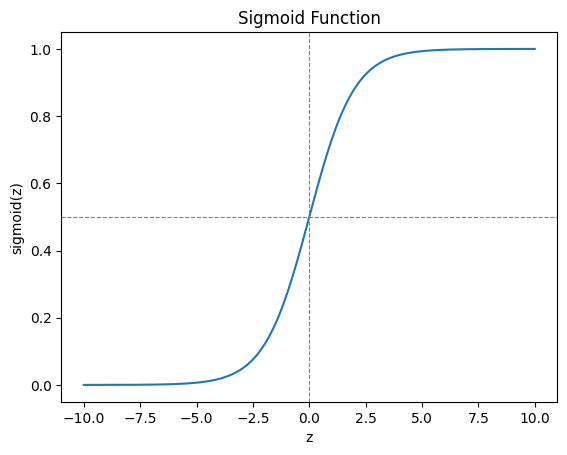

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizing the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.show()


## Question 10: Decision Boundary, Threshold, Confusion Matrix, and Metrics

### a) Decision Boundary in Logistic Regression

The decision boundary is the line (2D) or hyperplane (higher dimensions) separating the feature space into class prediction regions. In logistic regression, it is where the predicted probability equals exactly 0.5 — where the model is equally uncertain. Mathematically, this is where b0 + b1\*X1 + b2\*X2 = 0. Points on one side are classified as class 1; the other side as class 0. Logistic regression produces a linear decision boundary — it only separates linearly separable classes. For non-linear boundaries, polynomial features or non-linear models (Random Forest, Neural Networks) are needed.

### b) Role of Threshold in Classification

The threshold is the probability cutoff for converting continuous probability output into a binary class decision. Default: 0.5. However, it is a tunable business decision:

- Lower threshold (e.g., 0.3): More class-1 predictions — higher recall, lower precision. Good for medical diagnosis or fraud detection where missing a positive is costly.
- Higher threshold (e.g., 0.7): Fewer class-1 predictions — higher precision, lower recall. Good when false positives are costly (e.g., blocking a legitimate customer's account).

The optimal threshold depends on the relative business cost of false positives vs false negatives. ROC and Precision-Recall curves visualize this trade-off across all possible thresholds.

### c) TP, TN, FP, FN — The Confusion Matrix

- **True Positive (TP):** Predicted Positive AND actual is Positive. Correct detection. Example: Correctly identifying a fraudulent transaction as fraud.
- **True Negative (TN):** Predicted Negative AND actual is Negative. Correct rejection. Example: Correctly identifying a legitimate transaction as not fraud.
- **False Positive (FP) — Type I Error:** Predicted Positive BUT actual is Negative. False alarm. Example: Flagging a legitimate transaction as fraud. Costly when blocking a good customer.
- **False Negative (FN) — Type II Error:** Predicted Negative BUT actual is Positive. Missed detection. Example: Letting real fraud pass undetected. Costly when a missed positive has severe consequences.

### d) Evaluation Metrics Explained

- **Accuracy:** Formula: (TP + TN) / (TP + TN + FP + FN). Proportion of all correct predictions. Simple but misleading on imbalanced datasets — 99% accuracy on 1% fraud data is meaningless if zero fraud is caught.
- **Precision:** Formula: TP / (TP + FP). Of all predicted positives, how many were actually positive? High precision = few false alarms. Important when false positives are costly.
- **Recall (Sensitivity):** Formula: TP / (TP + FN). Of all actual positives, how many were detected? High recall = few missed positives. Critical when missing a positive is costly (fraud, cancer diagnosis).
- **F1-Score:** Formula: 2 \* (Precision \* Recall) / (Precision + Recall). Harmonic mean balancing precision and recall. The go-to metric for imbalanced datasets where both false positives and false negatives matter.
- **ROC Curve:** Plots True Positive Rate (Recall) vs False Positive Rate at every possible threshold. A curve bowing toward the top-left represents an excellent model. The diagonal line represents random guessing. Helps visualize the precision-recall trade-off across all thresholds.
- **AUC (Area Under ROC Curve):** AUC = 1.0: perfect discrimination. AUC = 0.5: random guessing. AUC = 0.85: the model correctly ranks a random positive above a random negative 85% of the time. Threshold-independent — ideal for comparing models on imbalanced datasets.
